<a href="https://colab.research.google.com/github/NehasriR/Black-and-White-Image-Colorisation/blob/main/Black_and_White_Image_Colorisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

APPROACH

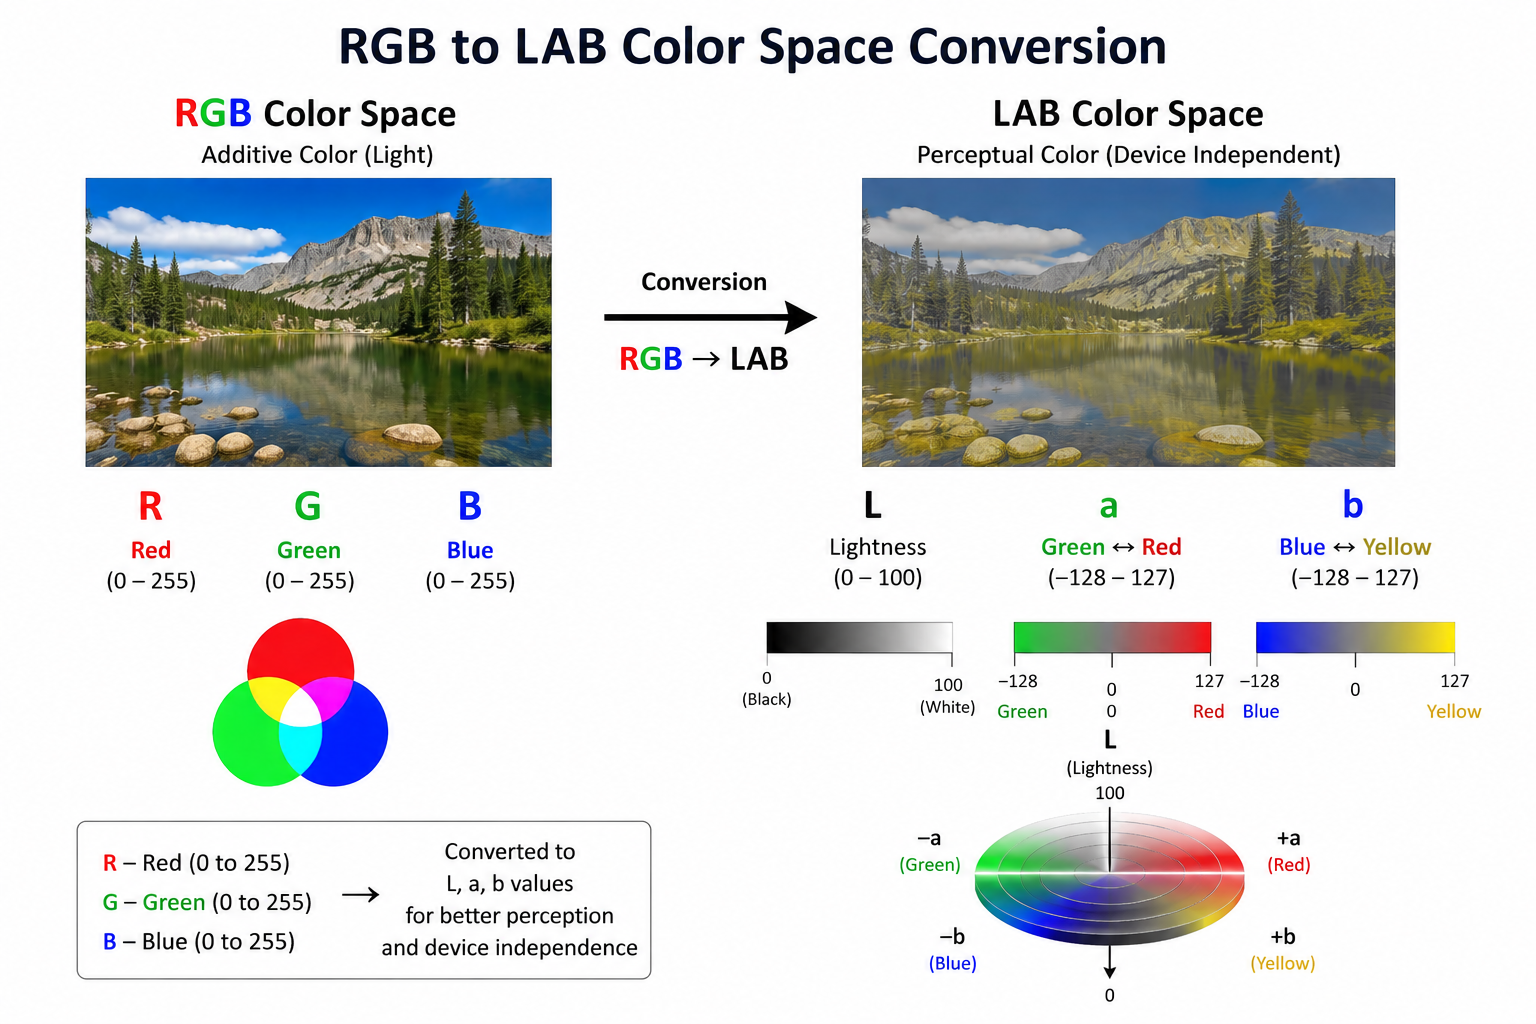

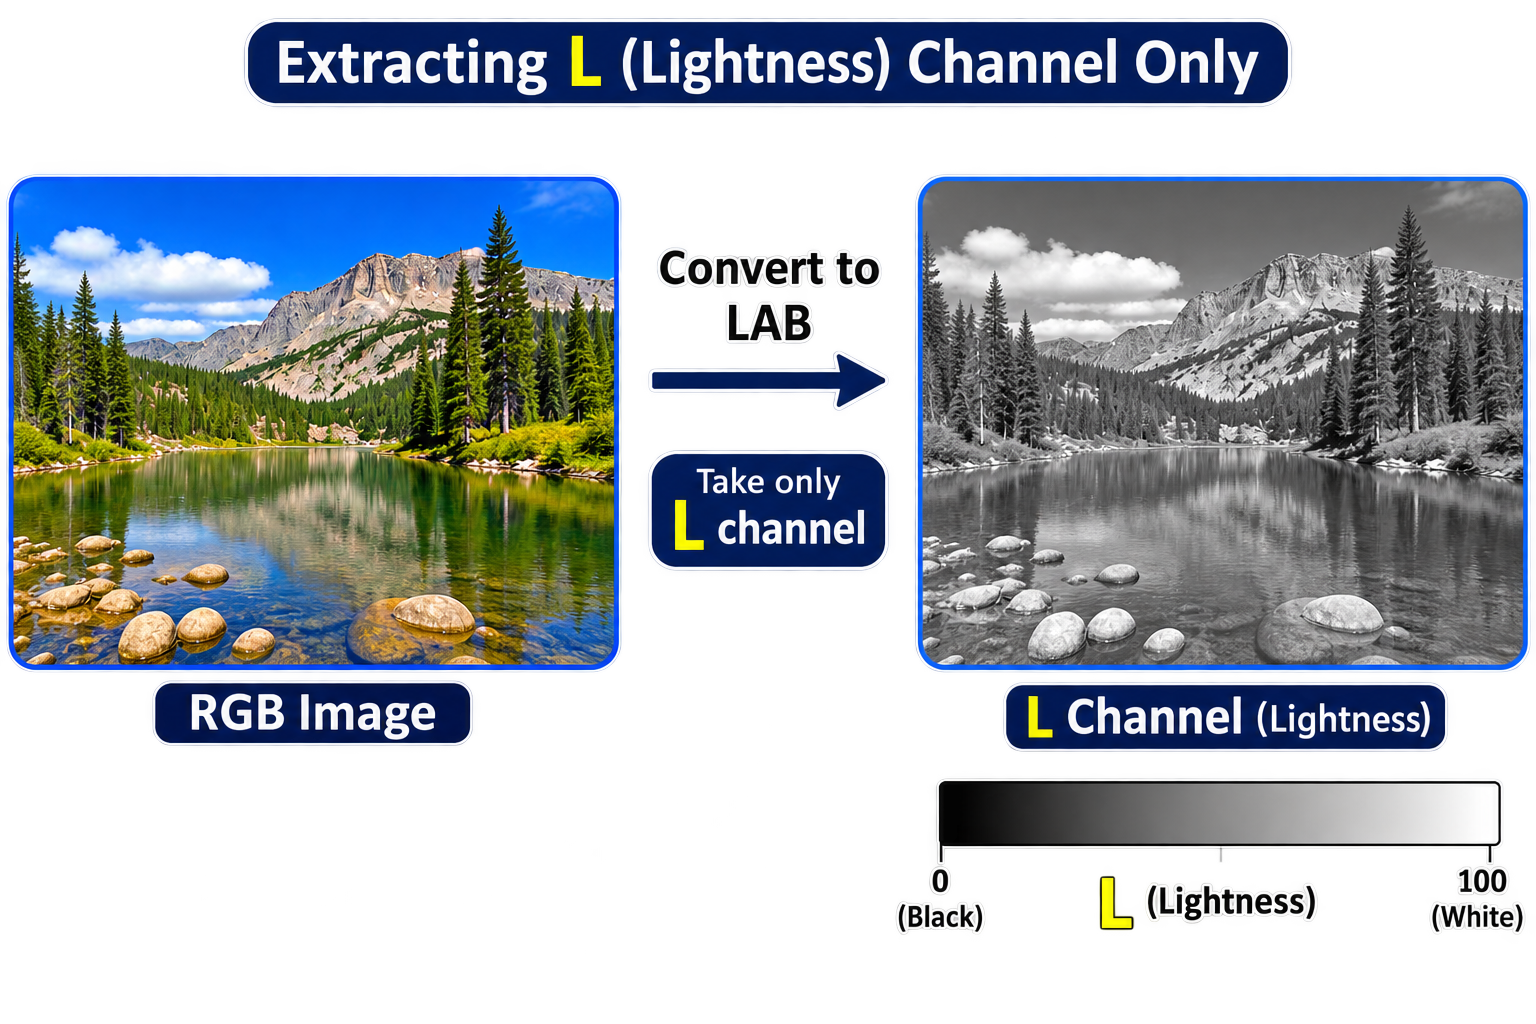

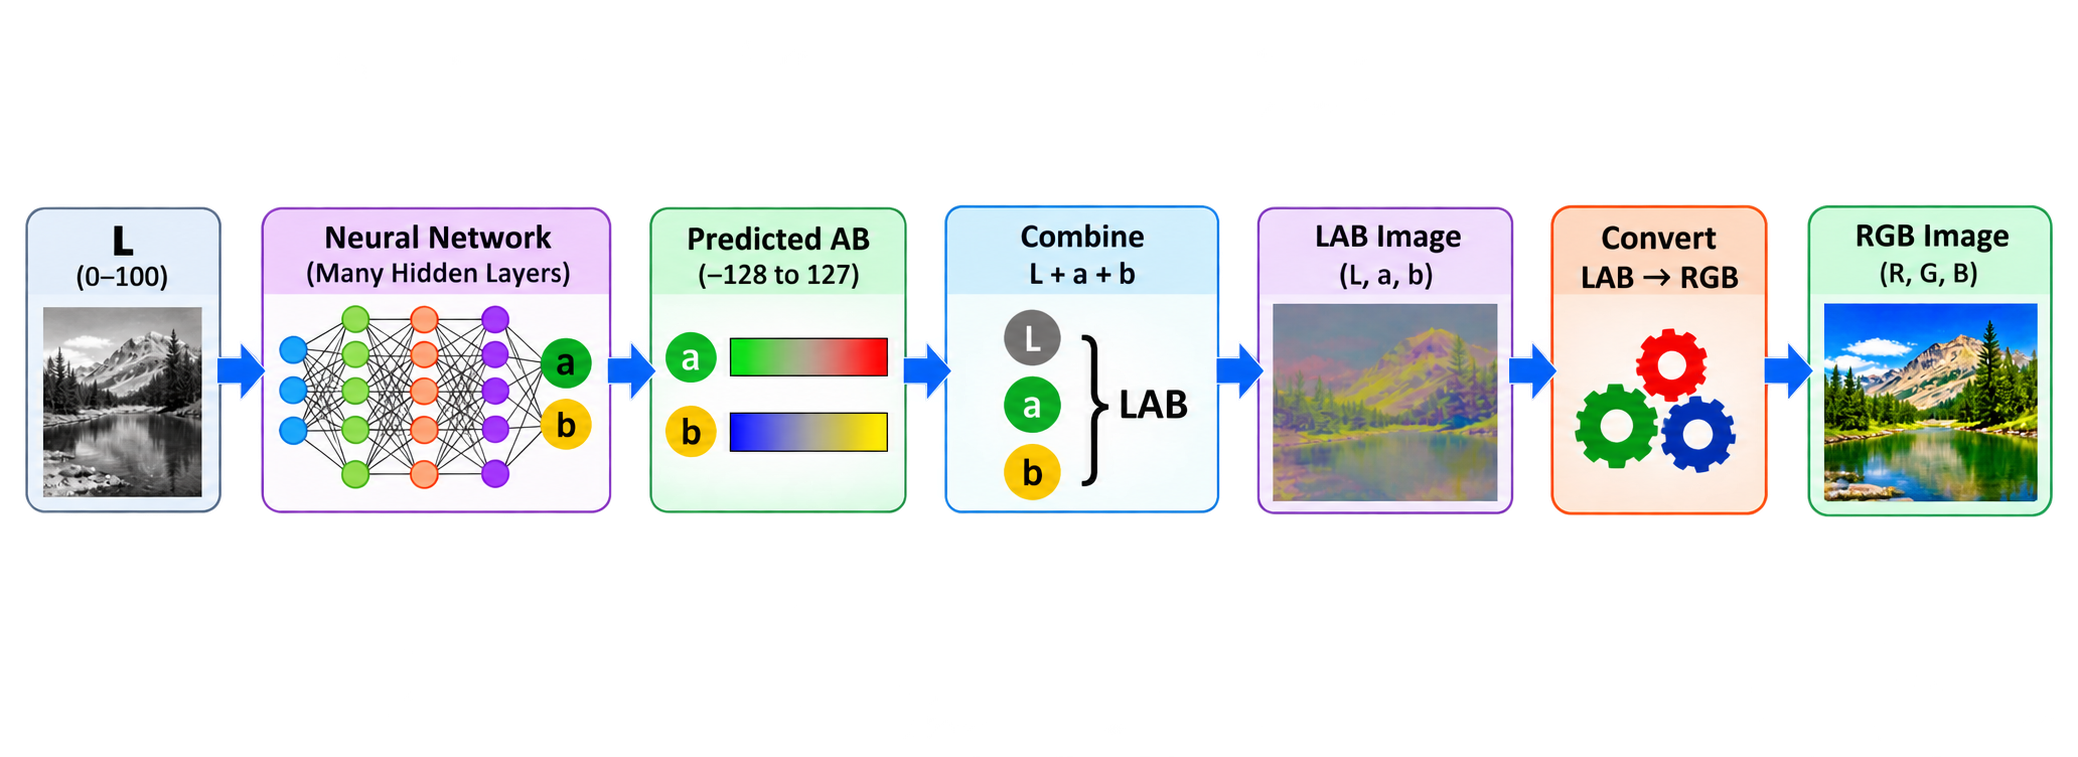

Import the necessary libraries

In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras import layers, Model
from google.colab import files

print("Libraries imported successfully!")

Libraries imported successfully!


Load the color Image dataset

In [ ]:
# Load CIFAR-10
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

# Use only 3,000 images
x_train = x_train[:3000]

print("Training images:", x_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1010s 6us/step
Training images: (3000, 32, 32, 3)


Converting Training Images to LAB

In [ ]:
L_train = []
AB_train = []

for image in x_train:

    # RGB → LAB
    lab = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2LAB
    )

    # L channel
    L = lab[:, :, 0]

    # AB channels
    AB = lab[:, :, 1:]

    # Normalize
    L = L.astype("float32") / 255.0
    AB = AB.astype("float32") / 255.0

    L_train.append(L)
    AB_train.append(AB)

L_train = np.array(L_train)
AB_train = np.array(AB_train)

# Add channel dimension to L
L_train = np.expand_dims(
    L_train,
    axis=-1
)

print("L shape:", L_train.shape)
print("AB shape:", AB_train.shape)

L shape: (3000, 32, 32, 1)
AB shape: (3000, 32, 32, 2)


MODEL

In [ ]:
def build_light_unet():

    inputs = layers.Input(
        shape=(32, 32, 1)
    )

    # Encoder 1
    c1 = layers.Conv2D(
        32,
        3,
        activation="relu",
        padding="same"
    )(inputs)

    c1 = layers.Conv2D(
        32,
        3,
        activation="relu",
        padding="same"
    )(c1)

    p1 = layers.MaxPooling2D(2)(c1)


    # Encoder 2
    c2 = layers.Conv2D(
        64,
        3,
        activation="relu",
        padding="same"
    )(p1)

    c2 = layers.Conv2D(
        64,
        3,
        activation="relu",
        padding="same"
    )(c2)

    p2 = layers.MaxPooling2D(2)(c2)


    # Bottleneck
    b = layers.Conv2D(
        128,
        3,
        activation="relu",
        padding="same"
    )(p2)

    b = layers.Conv2D(
        128,
        3,
        activation="relu",
        padding="same"
    )(b)


    # Decoder 1
    u1 = layers.UpSampling2D(2)(b)

    u1 = layers.Concatenate()(
        [u1, c2]
    )

    c3 = layers.Conv2D(
        64,
        3,
        activation="relu",
        padding="same"
    )(u1)

    c3 = layers.Conv2D(
        64,
        3,
        activation="relu",
        padding="same"
    )(c3)


    # Decoder 2
    u2 = layers.UpSampling2D(2)(c3)

    u2 = layers.Concatenate()(
        [u2, c1]
    )

    c4 = layers.Conv2D(
        32,
        3,
        activation="relu",
        padding="same"
    )(u2)

    c4 = layers.Conv2D(
        32,
        3,
        activation="relu",
        padding="same"
    )(c4)


    # Predict A and B
    outputs = layers.Conv2D(
        2,
        1,
        activation="sigmoid",
        padding="same"
    )(c4)


    model = Model(
        inputs,
        outputs
    )

    return model

In [ ]:
model = build_light_unet()

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 8, 64)  │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 8, 8, 128) │    147,584 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 32, 32,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32, 32,    │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │      9,248 │ conv2d_8[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 471,010 (1.80 MB)

 Trainable params: 471,010 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

Compile and train the model

In [ ]:
history = model.fit(
    L_train,
    AB_train,
    batch_size=64,
    epochs=5,
    validation_split=0.1,
    shuffle=True
)

Epoch 1/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - loss: 0.0028 - mae: 0.0364 - val_loss: 0.0027 - val_mae: 0.0346
Epoch 2/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.0028 - mae: 0.0360 - val_loss: 0.0026 - val_mae: 0.0340
Epoch 3/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0027 - mae: 0.0354 - val_loss: 0.0026 - val_mae: 0.0335
Epoch 4/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - loss: 0.0027 - mae: 0.0353 - val_loss: 0.0026 - val_mae: 0.0337
Epoch 5/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - loss: 0.0027 - mae: 0.0351 - val_loss: 0.0026 - val_mae: 0.0332


Training Performance

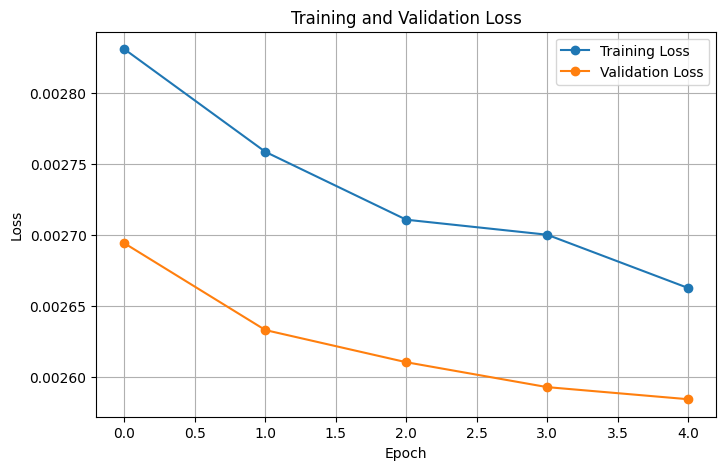

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()
plt.grid(True)

plt.show()

Black and white image uploading and coloring

In [ ]:
uploaded = files.upload()

image_name = list(uploaded.keys())[0]

image = cv2.imread(image_name)

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

# Resize to model input
gray_resized = cv2.resize(
    gray,
    (32, 32)
)

# Normalize
L_input = gray_resized.astype(
    "float32"
) / 255.0

# Add batch and channel dimensions
L_input = np.expand_dims(
    L_input,
    axis=0
)

L_input = np.expand_dims(
    L_input,
    axis=-1
)

# Predict AB
predicted_AB = model.predict(
    L_input
)[0]

print("Color prediction completed!")

Saving nature.jpg to nature.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step
Color prediction completed!


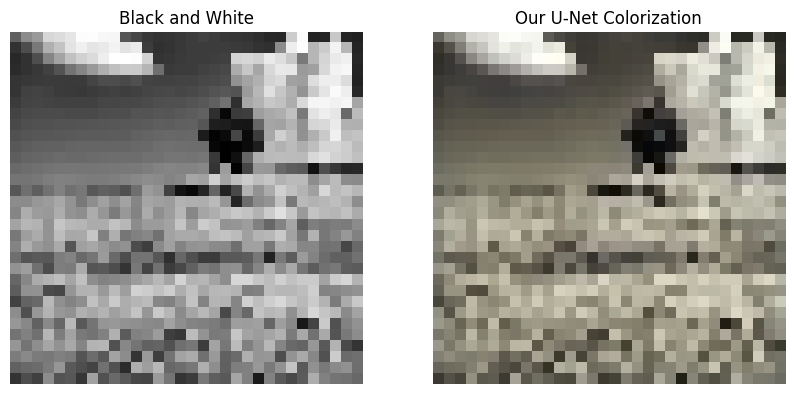

In [ ]:
# Create LAB image from grayscale

gray_bgr = cv2.cvtColor(
    gray_resized,
    cv2.COLOR_GRAY2BGR
)

lab = cv2.cvtColor(
    gray_bgr,
    cv2.COLOR_BGR2LAB
)

# Insert predicted AB channels
lab[:, :, 1:] = (
    predicted_AB * 255
).astype("uint8")

# LAB → RGB
colorized = cv2.cvtColor(
    lab,
    cv2.COLOR_LAB2RGB
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

plt.imshow(
    gray_resized,
    cmap="gray"
)

plt.title("Black and White")

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(colorized)

plt.title("Our U-Net Colorization")

plt.axis("off")

plt.show()